In [1]:
import optuna
import os, sys
import numpy as np
import pandas as pd
import networkx as nx
import time
import torch
from collections import defaultdict
from matplotlib import pyplot as plt
from dask.distributed import Client, progress, wait
from IPython.display import display, HTML
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import f1_score

module_path = os.path.abspath(os.path.join('..','..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.models.lr_ssd.snn__logn_gtv import SNN__LOGN_GTV
from tqdm import tqdm

from sklearn.metrics import precision_recall_curve, auc, roc_curve
from src.synthetic_data.generate_lr_data import generate_low_rank_data
from src.synthetic_data.generate_anomaly import generate_spatio_temporal_anomaly
from src.multilinear_ops.t2m import t2m

In [2]:

def get_data(data_variables):
    seed = data_variables['seed']
    lr_variables = data_variables['lowrank']
    graph_variables = data_variables['graph']
    an_variables = data_variables['anomaly']
    noise = data_variables.get('noise', None)

    X_gt = generate_low_rank_data(**lr_variables, seed=seed)
    std = lr_variables.get('std', None)
    if std is not None:
        X_gt = std*X_gt/ (X_gt.std())

    gtype = graph_variables['type']
    if gtype == 'grid':
        G = nx.grid_2d_graph(graph_variables['n'], graph_variables['m'], 
                             periodic=graph_variables.get('periodic', False))
    elif gtype == 'Gnm':
        G = nx.gnm_random_graph(graph_variables['n'], graph_variables['m'],
                                seed=graph_variables['seed'],
                                directed=graph_variables['directed'])
    elif gtype == 'random_regular':
        G = nx.random_regular_graph(graph_variables['d'], graph_variables['n'],
                                    seed=graph_variables['seed'])
    else:
        raise ValueError('Invalid graph type')
    
    Gt = nx.grid_graph((X_gt.shape[an_variables['time_m']-1], ), periodic=False)
    
    S_gt, labels = generate_spatio_temporal_anomaly(X_gt.shape, G, 
                                                    **an_variables,
                                                    seed=seed)
    
    if noise is not None:
        power_X_db = 10*np.log(np.linalg.norm(X_gt))
        power_N_db = power_X_db - noise['SNR']
        power_N = 10**(power_N_db/10)
        N = np.random.randn(*X_gt.shape)
        N = N/np.linalg.norm(N)*np.sqrt(power_N)
        Y = X_gt + S_gt + N
    else:
        Y = X_gt + S_gt
    return {'Y': Y, 'X_gt': X_gt, 'S_gt': S_gt, 'G':G, 'labels': labels, 'Gt': Gt}


def calculate_metrics(results, data):
    model = results['model']
    X_gt = data['X_gt']
    S_gt = data['S_gt']
    labels = data['labels']
    device = model.device
    fpr, tpr, thresholds = roc_curve(labels.ravel(),
                                    torch.abs(model.S).ravel().cpu().numpy())
    precision, recall, thresholds = precision_recall_curve(labels.ravel(),
                                        torch.abs(model.S).ravel().cpu().numpy())
    auc_prc_score = auc(recall, precision)
    auc_roc_score = auc(fpr, tpr)
    bic, k = model.bayesian_information_criterion()
    metrics = {'BIC': bic,
                'num_params': k,
               'AUC-ROC':auc_roc_score,
               'AUC-PRC':auc_prc_score,
               'S_err': (torch.norm(torch.tensor(S_gt, device=device)-model.S).cpu().numpy()/np.linalg.norm(S_gt)).item(),
               'L_err': (torch.norm(torch.tensor(X_gt, device=device)-model.X).cpu().numpy()/np.linalg.norm(X_gt)).item()
                }
    return metrics

In [3]:
data_variables = {
  'lowrank':{
    'dim': [225, 50, 24],
    'ranks': [10, 5, 5]
  },
  'graph':{
    'type': "grid",
    'n': 15,
    'm': 15,
    'periodic': False,
    'seed': 0,
  },
  'anomaly':{
    'amplitude': 0.25,
    'num_anomalies': 300,
    'duration': 8,
    'radius': 2,
    'window_type': 'boxcar', #'cosine', 'boxcar'
    'distribution': 'uniform',
    'local_dist': 'constant',
    'time_m': 3,
    'local_m': 1,
    'anomaly_spread': 'isotropic',
  },
   'noise':{
    'type': 'AWGN',
    'SNR': 10,
    },
  'seed':1,
}

data = get_data(data_variables)
## Control Variables
Y = data['Y']

snn_logn_gtv_select = {}
snn_logn_gtv_select['lr_modes'] = [1,2,3]
snn_logn_gtv_select['graph_modes'] = [1]
snn_logn_gtv_select['grouping'] = 'neighbor'
snn_logn_gtv_select['weighing'] = 'size_normalized_inv'
snn_logn_gtv_select['r_hop'] = 1
snn_logn_gtv_select['device'] = 'cuda:1'
snn_logn_gtv_select['dtype'] = torch.float64
snn_logn_gtv_select['verbose'] = 0
snn_logn_gtv_select['gtvr_config'] = [
                      {'graph':'spatial',
                       'mode':[1],
                       'p': 2,
                       'variation_type': 'GTV',
                       },
                       {'graph':'temporal',
                        'mode':[3], 
                        'variation_type': 'GTV',
                        'p':1}
                        ]

snn_logn_select = {}
snn_logn_select['lr_modes'] = [1,2,3]
snn_logn_select['graph_modes'] = [1]
snn_logn_select['grouping'] = 'neighbor'
snn_logn_select['weighing'] = 'size_normalized_inv'
snn_logn_select['r_hop'] = 1
snn_logn_select['device'] = 'cuda:1'
snn_logn_select['dtype'] = torch.float64
snn_logn_select['verbose'] = 0
snn_logn_select['gtvr_config'] = []



horpca_select = {}
horpca_select['lr_modes'] = [1,2,3]
horpca_select['graph_modes'] = [1]
horpca_select['grouping'] = 'neighbor'
horpca_select['weighing'] = 'uniform'
horpca_select['r_hop'] = 0
horpca_select['device'] = 'cuda:1'
horpca_select['dtype'] = torch.float64
horpca_select['verbose'] = 0
horpca_select['gtvr_config'] = []


In [5]:
data = get_data(data_variables)
G = data['G']
S_gt = data['S_gt']
an_m = data['labels']
Y = data['Y']
X = data['X_gt']

psi = 0.7
lda_1 = 1-psi
var2 = {}
var2['psis'] = [psi]*3
var2['lda'] = 1-psi
var2['max_iter'] = 1000
var2['rho'] = 4*np.abs(Y).sum()/Y.size
var2['err_tol'] = 1e-6
var2['rho_update'] = 1
var2['rho_update_thr'] = 100
snn_logn_gtv_select['verbose'] = 1
lda_l = 0.0001
lda_t = 0.0001
var2['lda_gtvs'] = [lda_l, lda_t]
model = SNN__LOGN_GTV(Y, G, **snn_logn_gtv_select)
L, S = model(**var2)

It-0 	# |r| = 2.1790e+01 	|s| = 1.3643e+00 	 obj = 0.0000e+00 	 0.041 sec.
It-1 	# |r| = 1.6886e+01 	|s| = 1.9606e+00 	 obj = 6.0660e-01 	 0.052 sec.
It-2 	# |r| = 1.1368e+01 	|s| = 2.3201e+00 	 obj = 2.1572e+00 	 0.041 sec.
It-3 	# |r| = 6.4920e+00 	|s| = 2.1210e+00 	 obj = 2.6907e+00 	 0.057 sec.
It-4 	# |r| = 4.3431e+00 	|s| = 1.7561e+00 	 obj = 2.0983e+00 	 0.038 sec.
It-5 	# |r| = 5.2493e+00 	|s| = 1.2826e+00 	 obj = 2.1739e+00 	 0.038 sec.
It-6 	# |r| = 6.0467e+00 	|s| = 7.7859e-01 	 obj = 2.3065e+00 	 0.038 sec.
It-7 	# |r| = 5.8970e+00 	|s| = 4.7071e-01 	 obj = 2.4111e+00 	 0.038 sec.
It-8 	# |r| = 5.1340e+00 	|s| = 5.6546e-01 	 obj = 2.4182e+00 	 0.037 sec.
It-9 	# |r| = 4.6463e+00 	|s| = 7.5081e-01 	 obj = 2.4215e+00 	 0.036 sec.
It-10 	# |r| = 5.1691e+00 	|s| = 8.4090e-01 	 obj = 2.8642e+00 	 0.036 sec.
It-11 	# |r| = 6.3497e+00 	|s| = 8.1515e-01 	 obj = 3.6906e+00 	 0.036 sec.
It-12 	# |r| = 7.4643e+00 	|s| = 7.0462e-01 	 obj = 4.6881e+00 	 0.036 sec.
It-13 	# |r| = 8.0133e

In [4]:

def search_hp(data_variables, model_name, n_trials, study_name):
    data = get_data(data_variables)
    G = data['G']
    S_gt = data['S_gt']
    an_m = data['labels']
    Y = data['Y']
    X = data['X_gt']
    A = nx.adjacency_matrix(G)

    study = optuna.create_study(study_name=study_name, direction='minimize', 
                                storage='sqlite:///exp4_snn_logn_gtv.db', load_if_exists=True)
    def objective(trial):
        psi = trial.suggest_float('psi', 0, 1)
        lda_1 = 1-psi
        var2 = {}
        var2['psis'] = [psi]*3
        var2['lda'] = 1-psi
        var2['max_iter'] = 100
        var2['rho'] = 4*np.abs(Y).sum()/Y.size
        var2['err_tol'] = 1e-6
        var2['rho_update'] = 1
        var2['rho_update_thr'] = 100
        if model_name == '[SNN]-[LOGN+GTV]':
            lda_l = trial.suggest_float('lda_l', 1e-8, 10, log=True)
            lda_t = trial.suggest_float('lda_t', 1e-8, 10, log=True)
            var2['lda_gtvs'] = [lda_l, lda_t]
            model = SNN__LOGN_GTV(Y, G, **snn_logn_gtv_select)
        elif model_name == '[SNN]-[LOGN]':
            lda_t = 0
            lda_l = 0
            var2['lda_gtvs'] = [lda_t]
            model = SNN__LOGN_GTV(Y, G, **snn_logn_select)
        elif model_name == 'HoRPCA':
            lda_t = 0
            lda_l = 0
            var2['lda_gtvs'] = []
            model = SNN__LOGN_GTV(Y, G, **horpca_select)
        
        trial.set_user_attr('psi', psi)
        trial.set_user_attr('lda_1', lda_1)
        trial.set_user_attr('lda_t', lda_t)
        trial.set_user_attr('lda_l', lda_l)
        trial.set_user_attr('number_of_anomalies', noa)
        trial.set_user_attr('anomaly_cardinality', int(an_m.sum()))
        trial.set_user_attr('duration', duration)

        
        L, S = model(**var2) # Run the model
        metrics = calculate_metrics({'model': model}, data)
        
        trial.set_user_attr('BIC', metrics['BIC'])
        trial.set_user_attr('num_params', metrics['num_params'])
        trial.set_user_attr('AUC-PRC', metrics['AUC-PRC'])
        trial.set_user_attr('AUC-ROC', metrics['AUC-ROC'])
        trial.set_user_attr('S_err', metrics['S_err'])
        trial.set_user_attr('L_err', metrics['L_err'])
        
        return metrics['AUC-PRC'] # metrics['BIC'] #
    study.optimize(objective, n_trials=n_trials)
    return study

In [1]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
models = ['HoRPCA'] # '[SNN]-[LOGN+GTV]', '[SNN]-[LOGN]', 
duration = 8
n_trials = 50
radius = 2
SNRs = [30, 20, 10, 0, -10] 
window_type = 'boxcar'
noa = 350
seed = 2
study_name_prefix = 'exp_4_AUPRC_' + window_type + '_' + str(seed)
search_results = defaultdict(list)

for m, model in enumerate(models):
    print("Running for model: ", model)
    for i, snr in enumerate(SNRs):
        print("Running for SNR: ", snr)
        data_variables['anomaly']['radius'] = radius
        data_variables['anomaly']['radius'] = duration
        data_variables['anomaly']['num_anomalies'] = noa
        data_variables['noise']['SNR'] = snr
        data_variables['anomaly']['window_type'] = window_type
        data_variables['seed'] = seed

        study_name = f'{study_name_prefix}_{model}_{snr}'
        study = search_hp(data_variables, model, n_trials, study_name)
        best_trial = study.best_trial #max(study.best_trials, key=lambda x: x.values[1])
        lda_1_opt = best_trial.user_attrs['lda_1']
        lda_t_opt = best_trial.user_attrs['lda_t']
        lda_l_opt = best_trial.user_attrs['lda_l']
        psi_opt = best_trial.params['psi']
        bic = best_trial.user_attrs['BIC']
        auc_prc = best_trial.user_attrs['AUC-PRC']
        auc_roc = best_trial.user_attrs['AUC-ROC']
        s_err = best_trial.user_attrs['S_err']
        l_err = best_trial.user_attrs['L_err']
        
        res = {'model': model, 'SNR': snr, 'radius': radius,
               'duration': duration, 'noa': noa,
                'seed': seed, 'lda_1': lda_1_opt, 'lda_t': lda_t_opt,
                'lda_l': lda_l_opt, 'psi': psi_opt,
                'BIC': bic, 'AUC-PRC': auc_prc,
                'AUC-ROC': auc_roc, 'S_err': s_err, 'L_err': l_err}
        
        search_results[model].append(res)
    df = pd.DataFrame(search_results[model])
    df.to_csv(f'{study_name}.csv', index=False)

NameError: name 'optuna' is not defined

In [6]:
df_snn_logn_gtv = pd.read_csv('exp_4_AUPRC_boxcar_2_[SNN]-[LOGN+GTV]_-10.csv')
df_snn_logn = pd.read_csv('exp_4_AUPRC_boxcar_2_[SNN]-[LOGN]_-10.csv')
# df_horpca = pd.from_csv('exp_4_AUPRC_boxcar_2_HoRPCA_-30.csv')

In [19]:
df_snn_logn_gtv = pd.DataFrame(search_results['[SNN]-[LOGN+GTV]'])
df_snn_logn = pd.DataFrame(search_results['[SNN]-[LOGN]'])
df_horpca = pd.DataFrame(search_results['HoRPCA'])
df_horpca

,model,SNR,radius,duration,noa,seed,lda_1,lda_t,lda_l,psi,BIC,AUC-PRC,AUC-ROC,S_err,L_err
0,HoRPCA,30,2,6,250,1,0.019159,0,0,0.980841,5.544216e+06,0.881676,0.917439,0.356549,0.999993
1,HoRPCA,20,2,6,250,1,0.025668,0,0,0.974332,5.397248e+06,0.881595,0.916601,0.360071,0.999984
2,HoRPCA,10,2,6,250,1,0.037730,0,0,0.962270,5.418908e+06,0.869309,0.906313,0.394098,0.999964
3,HoRPCA,0,2,6,250,1,0.033560,0,0,0.966440,5.266133e+06,0.777402,0.836283,0.642711,0.999997
4,HoRPCA,-10,2,6,250,1,0.072888,0,0,0.927112,4.918311e+06,0.444631,0.633112,1.726780,0.999999


In [17]:
df_snn_logn_gtv

,model,SNR,radius,duration,noa,seed,lda_1,lda_t,lda_l,psi,BIC,AUC-PRC,AUC-ROC,S_err,L_err
0,[SNN]-[LOGN+GTV],30,2,6,250,1,0.040697,2.187612e-03,0.005633,0.959303,6.395988e+06,0.928053,0.951069,0.238881,0.669367
1,[SNN]-[LOGN+GTV],20,2,6,250,1,0.108806,1.128025e-08,0.000152,0.891194,6.352956e+06,0.949653,0.966211,0.168443,0.452970
2,[SNN]-[LOGN+GTV],10,2,6,250,1,0.025513,1.681496e-07,0.001301,0.974487,5.400267e+06,0.866671,0.907082,0.394036,0.999877
3,[SNN]-[LOGN+GTV],0,2,6,250,1,0.093150,2.655732e-07,0.000826,0.906850,4.820064e+06,0.774253,0.833059,0.642120,0.999987
4,[SNN]-[LOGN+GTV],-10,2,6,250,1,0.173443,4.650137e-07,0.000005,0.826557,4.642891e+06,0.444625,0.632490,1.728538,1.000418


In [17]:
snn_logn_gtv_auprc = [  0.949653, 0.866671, 0.774253, 0.444625]
snn_logn_gtv_auroc = [  0.966211, 0.907082,  0.833059, 0.632490]
snn_logn_auprc = [ 0.878840, 0.868042, 0.776949, 0.445880]
snn_logn_auroc = [ 0.915889, 0.906419, 0.835534, 0.633392]
snrs = [ 20, 10, 0, -10]

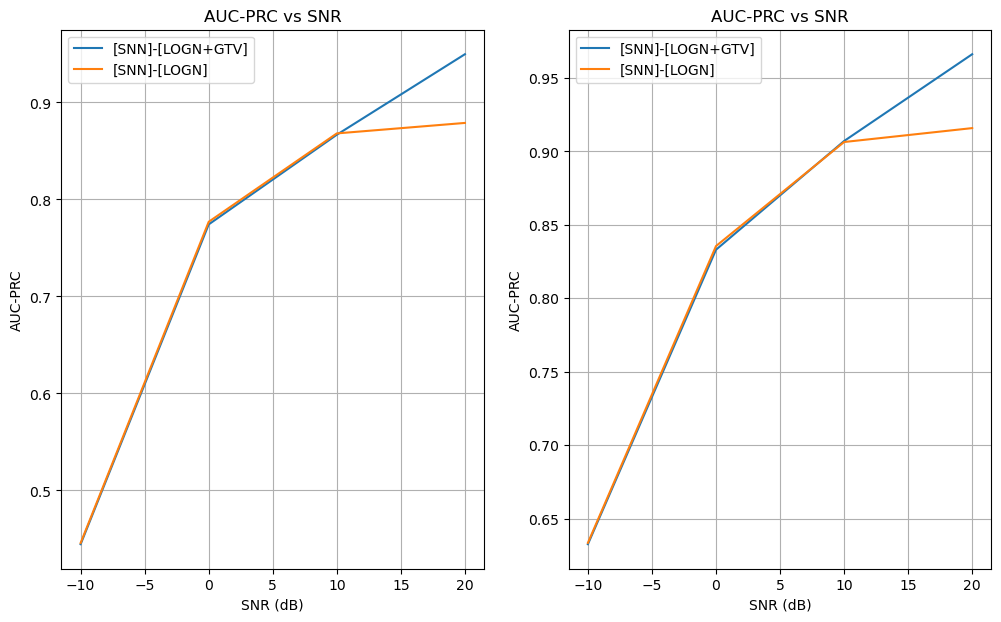

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# df_snn_logn_gtv.plot(x='SNR', y='AUC-ROC', ax=axes[0], marker='o', label='[SNN]-[LOGN+GTV]')
# df_snn_logn.plot(x='SNR', y='AUC-ROC', ax=axes[0], marker='o', label='[SNN]-[LOGN]')
# df_horpca.plot(x='SNR', y='AUC-ROC', ax=axes[0], marker='o', label='HoRPCA')
axes[0].plot(snrs, snn_logn_gtv_auprc, label='[SNN]-[LOGN+GTV]')
axes[0].plot(snrs, snn_logn_auprc, label='[SNN]-[LOGN]')
axes[0].set_title('AUC-PRC vs SNR')
axes[0].set_xlabel('SNR (dB)')
axes[0].set_ylabel('AUC-PRC')
axes[0].legend()
axes[0].grid()

axes[1].plot(snrs, snn_logn_gtv_auroc, label='[SNN]-[LOGN+GTV]')
axes[1].plot(snrs, snn_logn_auroc, label='[SNN]-[LOGN]')
# axes[1].
# df_snn_logn_gtv.plot(x='SNR', y='AUC-PRC', ax=axes[1], marker='o', label='[SNN]-[LOGN+GTV]')
# df_snn_logn.plot(x='SNR', y='AUC-PRC', ax=axes[1], marker='o', label='[SNN]-[LOGN]')
# df_horpca.plot(x='SNR', y='AUC-PRC', ax=axes[1], marker='o', label='HoRPCA')
axes[1].set_title('AUC-PRC vs SNR')
axes[1].set_xlabel('SNR (dB)')
axes[1].set_ylabel('AUC-PRC')
axes[1].legend()
axes[1].grid()

In [16]:
df_snn_logn

,model,SNR,radius,duration,noa,seed,lda_1,lda_t,lda_l,psi,BIC,AUC-PRC,AUC-ROC,S_err,L_err
0,[SNN]-[LOGN],30,2,6,250,1,0.022098,0,0,0.977902,5.472087e+06,0.882596,0.919193,0.356592,0.999999
1,[SNN]-[LOGN],20,2,6,250,1,0.052974,0,0,0.947026,5.052757e+06,0.878840,0.915889,0.360205,0.999984
2,[SNN]-[LOGN],10,2,6,250,1,0.058515,0,0,0.941485,5.008769e+06,0.868042,0.906419,0.394094,0.999992
3,[SNN]-[LOGN],0,2,6,250,1,0.108103,0,0,0.891897,4.767126e+06,0.776949,0.835534,0.642912,0.999993
4,[SNN]-[LOGN],-10,2,6,250,1,0.146221,0,0,0.853779,4.680762e+06,0.445880,0.633392,1.726417,1.000000
